# Analyse de robustesse multi-pays

**Objectif.** Évaluer la robustesse du pipeline entraîné sur l'Inde (scaler, imputer, modèle Keras + Isolation Forest) lorsqu'on l'applique aux autres pays (USA, UK, Canada, Australie)

## 1. Imports et chargement des artefacts Inde

In [16]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import keras
from sklearn.ensemble import IsolationForest

RNG = np.random.default_rng(42)
sns.set_theme(style="whitegrid")

DATA_DIR = "data"
MODEL_DIR = "model_final"
COUNTRIES = ["india", "usa", "uk", "canada", "australia"]
TARGET = "price_usd_normalized"
DROP_COLS = [TARGET, "calories"]  # mêmes features qu'à l'entraînement (train_india.py)
CONTINUOUS = ["serving_size_g", "protein_g", "total_fat_g", "total_carbs_g", "sodium_mg", "sugars_g"]

scaler = joblib.load(os.path.join(MODEL_DIR, "scaler_india.pkl"))
imputer = joblib.load(os.path.join(MODEL_DIR, "imputer_india.pkl"))
model = keras.models.load_model(os.path.join(MODEL_DIR, "model_india.keras"))

In [17]:
def load_country(name):
    df = pd.read_csv(os.path.join(DATA_DIR, f"data_{name}.csv"))
    X = df.drop(columns=DROP_COLS)
    y = df[TARGET].values
    return df, X, y

raw = {c: load_country(c) for c in COUNTRIES}
for c, (df, X, y) in raw.items():
    print(f"{c:10s} -> {df.shape[0]:5d} lignes, {X.shape[1]} features, NaN: {int(X.isna().sum().sum())}")

FEATURES = raw["india"][1].columns.tolist()
CONT_IDX = [FEATURES.index(c) for c in CONTINUOUS]
FEATURES

india      ->  2196 lignes, 13 features, NaN: 0
usa        ->  2721 lignes, 13 features, NaN: 0
uk         ->  1053 lignes, 13 features, NaN: 0
canada     ->   901 lignes, 13 features, NaN: 0
australia  ->   629 lignes, 13 features, NaN: 0


['serving_size_g',
 'protein_g',
 'total_fat_g',
 'total_carbs_g',
 'sodium_mg',
 'sugars_g',
 'avg_rating',
 'Non-Veg',
 'Veg',
 'Vegan',
 'budget',
 'mid',
 'premium']

## 2. Entraînement de l'Isolation Forest sur l'Inde

On applique d'abord l'imputer puis le scaler **figés** (entraînés à l'origine sur l'Inde) pour obtenir l'espace de référence, puis on entraîne l'Isolation Forest dans cet espace.

In [18]:
def to_model_space(X_df):
    """Applique imputer puis scaler (tous deux figés)."""
    return scaler.transform(imputer.transform(X_df))

X_india_scaled = to_model_space(raw["india"][1])
iforest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1,
)
iforest.fit(X_india_scaled)

scores_india = iforest.score_samples(X_india_scaled)  # plus élevé = plus normal
ROBUSTNESS_THRESHOLD = float(np.quantile(scores_india, 0.05))
print(f"Seuil de robustesse (5e percentile des scores Inde) : {ROBUSTNESS_THRESHOLD:.4f}")

joblib.dump(iforest, os.path.join(MODEL_DIR, "isolation_forest_india.pkl"))
with open(os.path.join(MODEL_DIR, "robustness_threshold.txt"), "w") as f:
    f.write(f"{ROBUSTNESS_THRESHOLD}\n")
print("Isolation Forest exportée -> model_final/isolation_forest_india.pkl")

Seuil de robustesse (5e percentile des scores Inde) : -0.5796
Isolation Forest exportée -> model_final/isolation_forest_india.pkl


**Définition de la zone de robustesse.** Un échantillon est considéré dans la zone si `iforest.score_samples(x) >= ROBUSTNESS_THRESHOLD`. Par construction, 95 % des points indiens sont dans la zone. Pour les autres pays, le `% dans la zone` mesure à quel point leur distribution ressemble à celle de l'Inde *dans l'espace du modèle*.

## 3. Scores d'anomalie par pays (données brutes)

In [19]:
def in_zone_pct(scores):
    return float((scores >= ROBUSTNESS_THRESHOLD).mean() * 100)

rows = []
scores_by_country = {}
for c in COUNTRIES:
    _, X, y = raw[c]
    Xs = to_model_space(X)
    s = iforest.score_samples(Xs)
    scores_by_country[c] = s
    y_pred = model.predict(Xs, verbose=0).flatten()
    mae = float(np.mean(np.abs(y_pred - y)))
    rows.append({
        "pays": c,
        "n": len(y),
        "score_moyen": float(s.mean()),
        "score_median": float(np.median(s)),
        "pct_en_zone": in_zone_pct(s),
        "MAE_baseline": mae,
    })
baseline = pd.DataFrame(rows).set_index("pays")
baseline

,n,score_moyen,score_median,pct_en_zone,MAE_baseline
pays,,,,,
india,2196,-0.497307,-0.494039,94.990893,1.107245
usa,2721,-0.497496,-0.492122,94.707828,5.828822
uk,1053,-0.499419,-0.493492,94.301994,6.865917
canada,901,-0.498820,-0.491746,94.450610,4.590016
australia,629,-0.496000,-0.491388,95.389507,5.439631


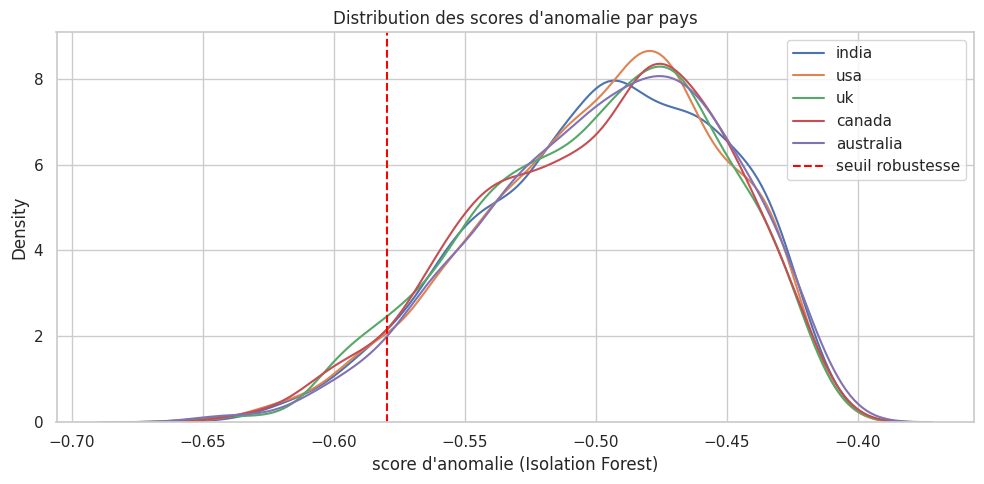

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
for c in COUNTRIES:
    sns.kdeplot(scores_by_country[c], ax=ax, label=c, fill=False)
ax.axvline(ROBUSTNESS_THRESHOLD, color="red", linestyle="--", label="seuil robustesse")
ax.set_xlabel("score d'anomalie (Isolation Forest)")
ax.set_title("Distribution des scores d'anomalie par pays")
ax.legend()
plt.tight_layout()

Pour chaque pays, on fait varier le seuil d'isolation et on trace la MAE calculée *uniquement sur les échantillons dont le score est ≥ seuil*, ainsi que la couverture associée (équivalent de la cellule 10 de `robustesse_imputation.ipynb`, adapté à la régression Keras et appliqué pays par pays).

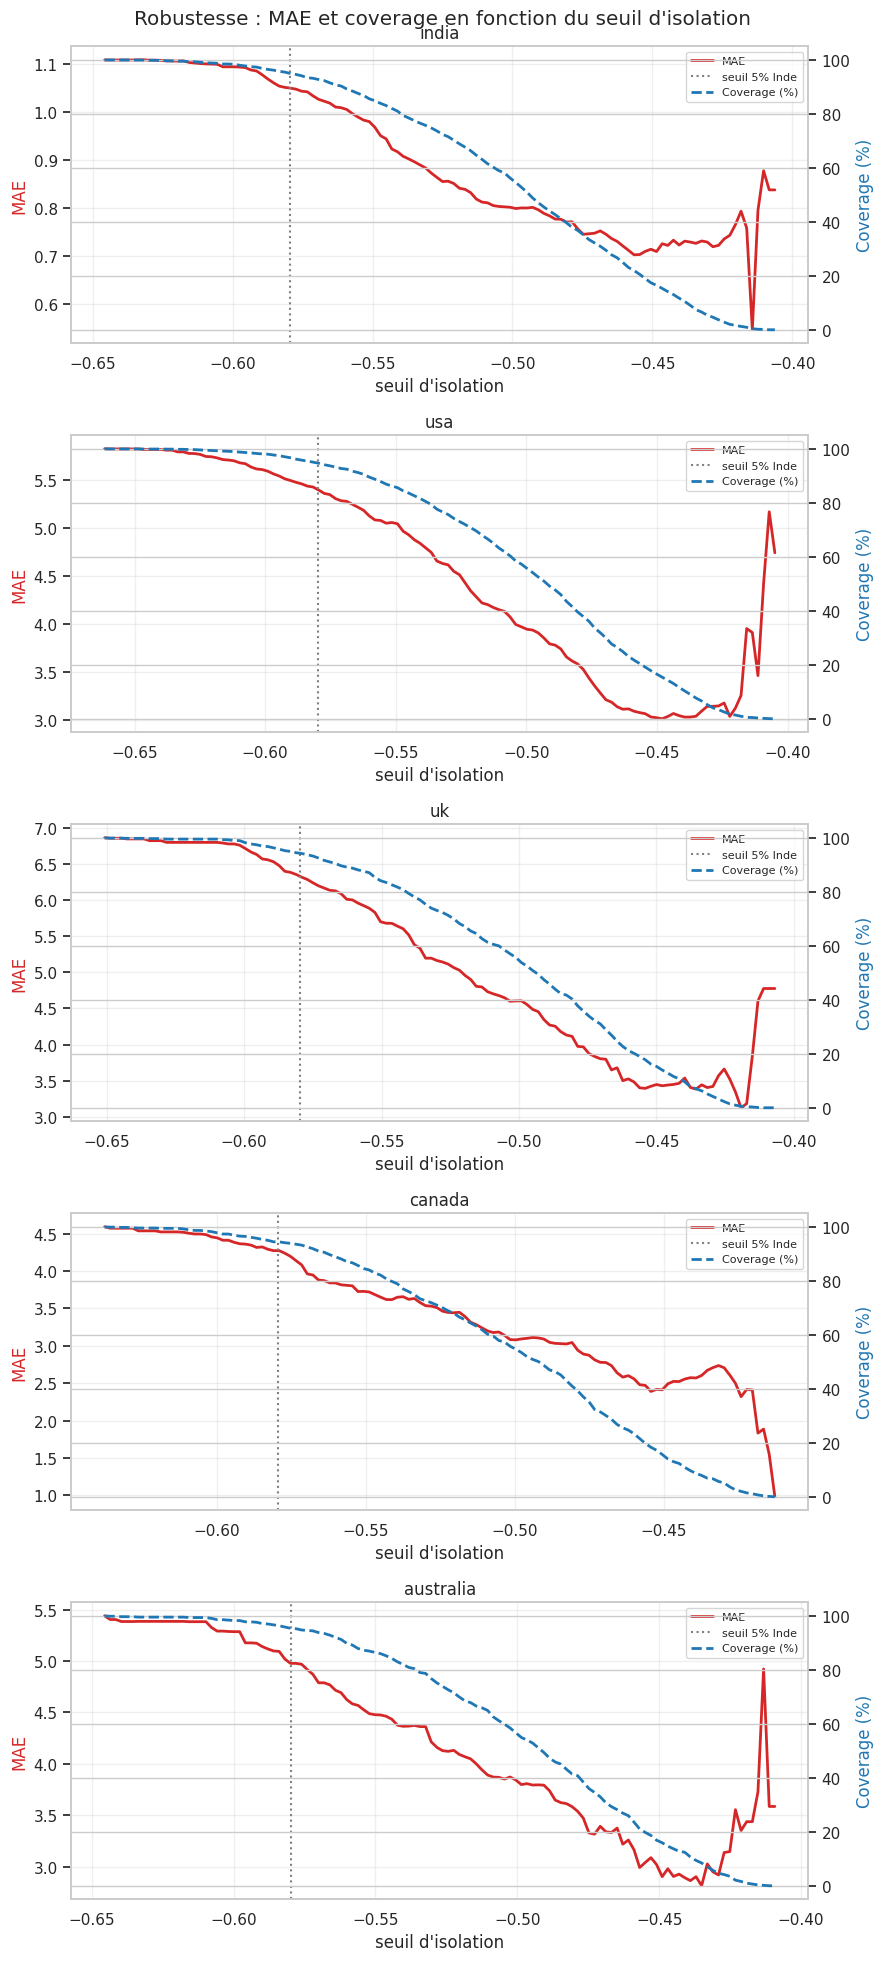

In [21]:
def build_threshold_grid(scores, n=120):
    s_min, s_max = float(np.min(scores)), float(np.max(scores))
    if np.isclose(s_min, s_max):
        return np.array([s_min])
    return np.linspace(s_min, s_max, n)

def mae_coverage_curve(scores, y_true, y_pred, thresholds):
    rows = []
    for th in thresholds:
        mask = scores >= th
        cov = float(mask.mean())
        mae = float(np.mean(np.abs(y_pred[mask] - y_true[mask]))) if mask.sum() else np.nan
        rows.append({"threshold": float(th), "mae": mae, "coverage": cov, "n_kept": int(mask.sum())})
    return pd.DataFrame(rows)

robustness_curves = {}
for c in COUNTRIES:
    _, X, y = raw[c]
    Xs = to_model_space(X)
    y_pred = model.predict(Xs, verbose=0).flatten()
    scores = scores_by_country[c]
    grid = build_threshold_grid(scores, n=120)
    robustness_curves[c] = mae_coverage_curve(scores, y, y_pred, grid)

fig, axes = plt.subplots(len(COUNTRIES), 1, figsize=(9, 4 * len(COUNTRIES)), sharey=False)
for ax_mae, c in zip(axes, COUNTRIES):
    df_r = robustness_curves[c]
    ax_cov = ax_mae.twinx()
    ax_mae.plot(df_r["threshold"], df_r["mae"], color="#d62728", linewidth=2.0, label="MAE")
    ax_cov.plot(df_r["threshold"], df_r["coverage"] * 100, color="#1f77b4",
                linewidth=2.0, linestyle="--", label="Coverage (%)")
    ax_mae.axvline(ROBUSTNESS_THRESHOLD, color="grey", linestyle=":", label="seuil 5% Inde")
    ax_mae.set_title(c)
    ax_mae.set_xlabel("seuil d'isolation")
    ax_mae.set_ylabel("MAE", color="#d62728")
    ax_cov.set_ylabel("Coverage (%)", color="#1f77b4")
    ax_mae.grid(True, alpha=0.3)
    l1, lab1 = ax_mae.get_legend_handles_labels()
    l2, lab2 = ax_cov.get_legend_handles_labels()
    ax_mae.legend(l1 + l2, lab1 + lab2, loc="best", fontsize=8)
fig.suptitle("Robustesse : MAE et coverage en fonction du seuil d'isolation")
plt.tight_layout()
plt.show()

## 4. Résistance au bruit

Pour chaque pays, on bruite **une seule feature continue à la fois** avec une intensité exprimée en % de son écart-type (cellule 8 de `analyse_bruit.ipynb`), puis on mesure la variation relative de la MAE par rapport à la baseline du pays.

india ok
usa ok
uk ok
canada ok
australia ok


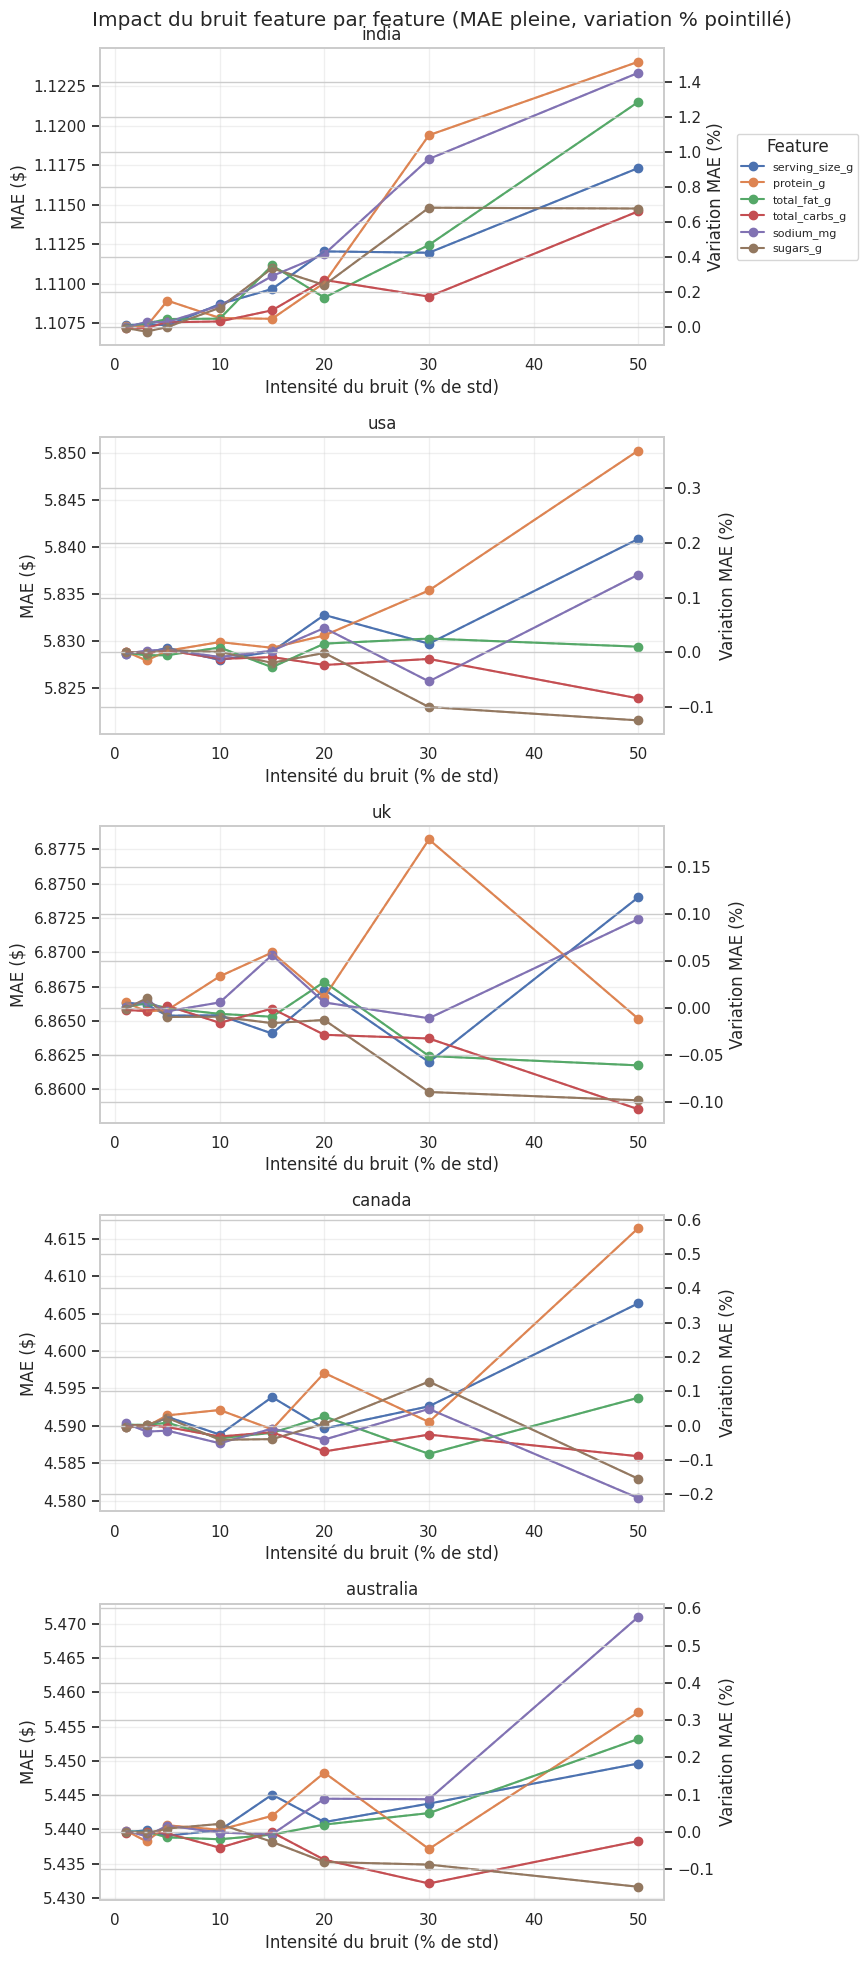

In [29]:
NOISE_INTENSITIES_PCT = np.array([1, 3, 5, 10, 15, 20, 30, 50])
N_REPEATS_FEAT = 1

def per_feature_noise_curve(X_df, y):
    """Retourne {feature: [MAE absolue pour chaque intensité]}."""
    out = {}
    for feat in CONTINUOUS:
        curve = []
        std_feat = float(X_df[feat].std())
        for intensity in NOISE_INTENSITIES_PCT:
            maes = []
            for _ in range(N_REPEATS_FEAT):
                X_n = X_df.copy()
                noise = RNG.normal(0.0, std_feat * intensity / 100.0, size=len(X_n))
                X_n[feat] = X_n[feat].to_numpy(dtype=float) + noise
                Xs = scaler.transform(imputer.transform(X_n))
                y_pred = model.predict(Xs, verbose=0).flatten()
                maes.append(float(np.mean(np.abs(y_pred - y))))
            curve.append(float(np.mean(maes)))
        out[feat] = curve
    return out

per_feat_noise_mae = {}
per_feat_noise = {}  # variation % (réutilisé en §6)
for c in COUNTRIES:
    _, X, y = raw[c]
    mae_base = float(baseline.loc[c, "MAE_baseline"])
    per_feat_noise_mae[c] = per_feature_noise_curve(X, y)
    per_feat_noise[c] = {
        f: [100.0 * (m - mae_base) / mae_base if mae_base else np.nan for m in curve]
        for f, curve in per_feat_noise_mae[c].items()
    }
    print(f"{c} ok")

fig, axes = plt.subplots(len(COUNTRIES), 1, figsize=(9, 4 * len(COUNTRIES)), sharey=False)
for ax_mae, c in zip(axes, COUNTRIES):
    ax_pct = ax_mae.twinx()
    mae_base = float(baseline.loc[c, "MAE_baseline"])
    for feat, curve in per_feat_noise_mae[c].items():
        arr = np.asarray(curve, dtype=float)
        line, = ax_mae.plot(NOISE_INTENSITIES_PCT, arr, marker="o", label=feat)
        pct_change = ((arr - mae_base) / mae_base * 100.0) if mae_base else np.full_like(arr, np.nan)
        ax_pct.plot(NOISE_INTENSITIES_PCT, pct_change, linestyle="--", alpha=0.5,
                    color=line.get_color())
    ax_mae.set_title(c)
    ax_mae.set_xlabel("Intensité du bruit (% de std)")
    ax_mae.set_ylabel("MAE ($)")
    ax_pct.set_ylabel("Variation MAE (%)")
    ax_mae.grid(True, alpha=0.3)
axes[0].legend(loc="center left", bbox_to_anchor=(1.12, 0.5), fontsize=8, title="Feature")
fig.suptitle("Impact du bruit feature par feature (MAE pleine, variation % pointillé)")
plt.tight_layout()
plt.show()

## 5. Résistance à l'imputation

Pour chaque pays, on injecte des NaN dans **une seule feature continue à la fois** et on suit la MAE après imputation par l'imputer figé (cellule 14 de `robustesse_imputation.ipynb`). Trait plein = MAE absolue, trait pointillé (axe droit) = variation relative en % par rapport à la baseline du pays.

india ok
usa ok
uk ok
canada ok
australia ok


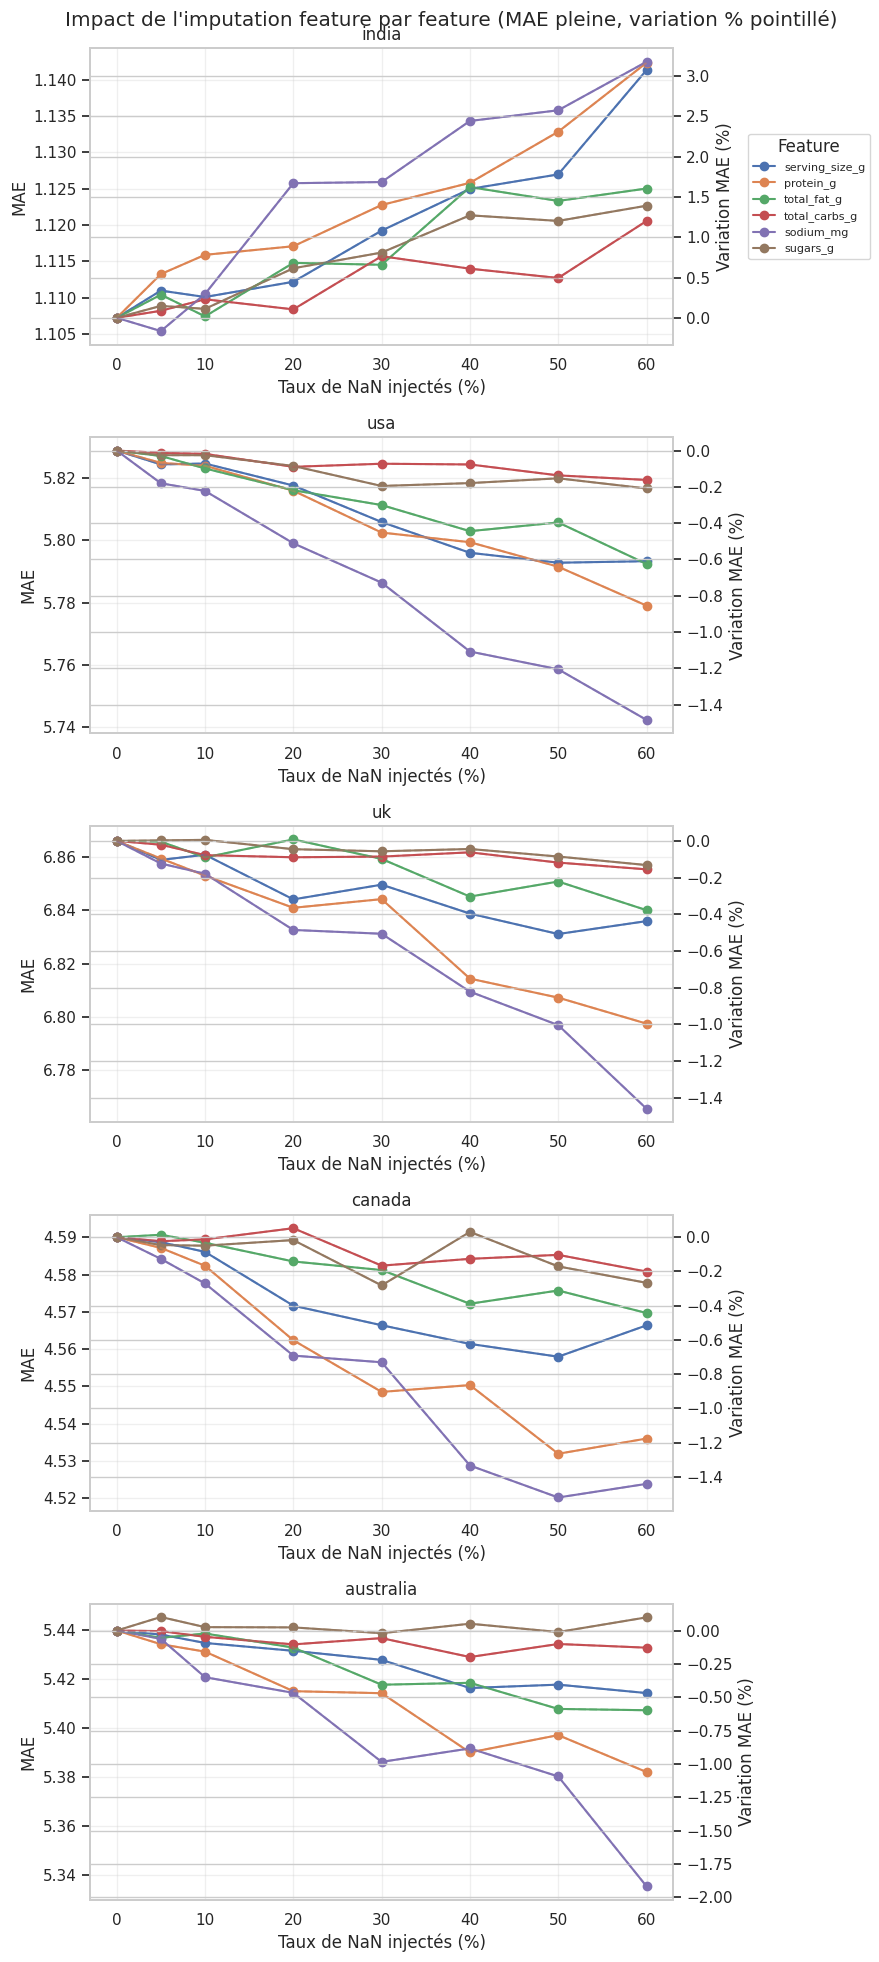

In [25]:
MISSING_RATES_FEAT = np.array([0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60])
N_REPEATS_IMP = 1

def per_feature_imputation_curve(X_df, y):
    """Retourne {feature: [MAE pour chaque taux]}."""
    out = {}
    for feat in CONTINUOUS:
        curve = []
        for rate in MISSING_RATES_FEAT:
            maes = []
            for _ in range(N_REPEATS_IMP):
                X_m = X_df.copy()
                n_rows = len(X_m)
                n_drop = int(np.floor(rate * n_rows))
                if n_drop > 0:
                    idx = RNG.choice(n_rows, size=n_drop, replace=False)
                    X_m.iloc[idx, X_m.columns.get_loc(feat)] = np.nan
                Xs = scaler.transform(imputer.transform(X_m))
                y_pred = model.predict(Xs, verbose=0).flatten()
                maes.append(float(np.mean(np.abs(y_pred - y))))
            curve.append(float(np.mean(maes)))
        out[feat] = curve
    return out

per_feat_imp = {}
for c in COUNTRIES:
    _, X, y = raw[c]
    per_feat_imp[c] = per_feature_imputation_curve(X, y)
    print(f"{c} ok")

fig, axes = plt.subplots(len(COUNTRIES), 1, figsize=(9, 4 * len(COUNTRIES)), sharey=False)
for ax_mae, c in zip(axes, COUNTRIES):
    ax_pct = ax_mae.twinx()
    mae_base = float(baseline.loc[c, "MAE_baseline"])
    for feat, curve in per_feat_imp[c].items():
        arr = np.asarray(curve, dtype=float)
        line, = ax_mae.plot(MISSING_RATES_FEAT * 100, arr, marker="o", label=feat)
        pct_change = ((arr - mae_base) / mae_base * 100.0) if mae_base else np.full_like(arr, np.nan)
        ax_pct.plot(MISSING_RATES_FEAT * 100, pct_change, linestyle="--", alpha=0.5,
                    color=line.get_color())
    ax_mae.set_title(c)
    ax_mae.set_xlabel("Taux de NaN injectés (%)")
    ax_mae.set_ylabel("MAE")
    ax_pct.set_ylabel("Variation MAE (%)")
    ax_mae.grid(True, alpha=0.3)
axes[0].legend(loc="center left", bbox_to_anchor=(1.12, 0.5), fontsize=8, title="Feature")
fig.suptitle("Impact de l'imputation feature par feature (MAE pleine, variation % pointillé)")
plt.tight_layout()
plt.show()

## 6. Zone de robustesse par pays / source

Les expériences §4.bis et §5.bis montrent que même avec **60 % de NaN ou 50 % de bruit sur une feature**, la MAE varie de quelques % seulement. On utilise donc un critère serré, cohérent avec ces ordres de grandeur :

> **Zone de robustesse =** plus grand niveau de perturbation tel que la **feature la plus sensible** ne fasse pas dépasser **±3 % de variation MAE** par rapport à la baseline du pays.

On reporte également, pour chaque pays, la feature qui se révèle la plus sensible.

In [27]:
MAE_VARIATION_MAX_PCT = 3.0

def max_noise_intensity_per_country(per_feat_noise_country, max_var_pct=MAE_VARIATION_MAX_PCT):
    """Plus forte intensité de bruit (% std) tolérée sur la feature LA PLUS sensible."""
    worst_per_intensity = []
    for k, intensity in enumerate(NOISE_INTENSITIES_PCT):
        worst = max(abs(curve[k]) for curve in per_feat_noise_country.values())
        worst_per_intensity.append((intensity, worst))
    ok = [i for i, v in worst_per_intensity if v <= max_var_pct]
    return float(max(ok)) if ok else float("nan")

def max_missing_rate_per_country(per_feat_imp_country, mae_base, max_var_pct=MAE_VARIATION_MAX_PCT):
    """Plus fort taux de NaN toléré sur la feature LA PLUS sensible."""
    worst_per_rate = []
    for k, rate in enumerate(MISSING_RATES_FEAT):
        worst = max(
            abs((curve[k] - mae_base) / mae_base * 100.0) if mae_base else np.nan
            for curve in per_feat_imp_country.values()
        )
        worst_per_rate.append((rate, worst))
    ok = [r for r, v in worst_per_rate if v <= max_var_pct]
    return float(max(ok)) if ok else float("nan")

summary = []
for c in COUNTRIES:
    mae_base = float(baseline.loc[c, "MAE_baseline"])
    # Pire feature au pic de bruit max
    worst_noise_feat, worst_noise_val = max(
        ((f, abs(curve[-1])) for f, curve in per_feat_noise[c].items()),
        key=lambda x: x[1],
    )
    # Pire feature au taux d'imputation max
    worst_imp_feat, worst_imp_val_mae = max(
        ((f, abs((curve[-1] - mae_base) / mae_base * 100.0) if mae_base else 0.0)
         for f, curve in per_feat_imp[c].items()),
        key=lambda x: x[1],
    )
    summary.append({
        "pays": c,
        "MAE_baseline": round(mae_base, 3),
        "pct_en_zone_baseline": round(float(baseline.loc[c, "pct_en_zone"]), 2),
        "noise_intensity_max_pct_std": max_noise_intensity_per_country(per_feat_noise[c]),
        "p_nan_max": max_missing_rate_per_country(per_feat_imp[c], mae_base),
        "feature_la_plus_sensible_bruit": f"{worst_noise_feat} ({worst_noise_val:.1f}%)",
        "feature_la_plus_sensible_imputation": f"{worst_imp_feat} ({worst_imp_val_mae:.1f}%)",
    })
summary_df = pd.DataFrame(summary).set_index("pays")
summary_df.to_csv("robustness_summary_multi_pays.csv")
summary_df

,MAE_baseline,pct_en_zone_baseline,noise_intensity_max_pct_std,p_nan_max,feature_la_plus_sensible_bruit,feature_la_plus_sensible_imputation
pays,,,,,,
india,1.107,94.99,50.0,0.5,protein_g (1.9%),sodium_mg (3.2%)
usa,5.829,94.71,50.0,0.6,protein_g (0.2%),sodium_mg (1.5%)
uk,6.866,94.30,50.0,0.6,sodium_mg (0.3%),sodium_mg (1.5%)
canada,4.590,94.45,50.0,0.6,sodium_mg (0.6%),sodium_mg (1.4%)
australia,5.440,95.39,50.0,0.6,sugars_g (0.4%),sodium_mg (1.9%)


## Analyse de redondance

Le fait qu'on puisse imputer (ou bruiter) **n'importe quelle feature continue** sans dégrader sensiblement la MAE est suspect : cela suggère que les features portent une **information redondante**. Si une feature est fortement corrélée à d'autres, l'imputer par la médiane revient à perdre peu d'information, car le modèle peut reconstruire la prédiction à partir des features restantes.

On vérifie cette hypothèse en regardant :
1. la **matrice de corrélation** entre features continues (sur les données Inde) ;
2. pour chaque feature, le **R²** obtenu en la prédisant à partir des autres (proxy de redondance).

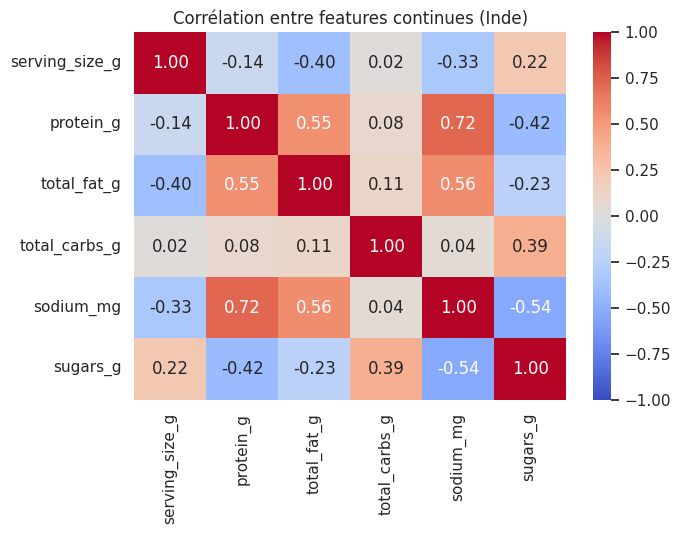

,R2_prédite_par_les_autres
feature,
sodium_mg,0.644
protein_g,0.583
sugars_g,0.472
total_fat_g,0.440
total_carbs_g,0.248
serving_size_g,0.228


In [28]:
from sklearn.linear_model import LinearRegression

# 1. Matrice de corrélation des features continues (sur l'Inde)
X_india_cont = raw["india"][1][CONTINUOUS].apply(pd.to_numeric, errors="coerce")
X_india_cont = pd.DataFrame(imputer.transform(raw["india"][1]), columns=FEATURES)[CONTINUOUS]
corr = X_india_cont.corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Corrélation entre features continues (Inde)")
plt.tight_layout()
plt.show()

# 2. R² de prédiction de chaque feature à partir des autres (redondance)
redundancy_rows = []
for feat in CONTINUOUS:
    others = [c for c in CONTINUOUS if c != feat]
    lr = LinearRegression().fit(X_india_cont[others], X_india_cont[feat])
    r2 = float(lr.score(X_india_cont[others], X_india_cont[feat]))
    redundancy_rows.append({"feature": feat, "R2_prédite_par_les_autres": round(r2, 3)})
redundancy_df = pd.DataFrame(redundancy_rows).set_index("feature").sort_values(
    "R2_prédite_par_les_autres", ascending=False
)
redundancy_df

## 7. Analyse et interprétation des résultats observés

### 7.1 Scores d'anomalie de base

| pays | n | score moyen | % en zone | MAE baseline |
|---|---|---|---|---|
| india | 2 196 | −0.497 | 94.99 % | **1.11** |
| usa | 2 721 | −0.497 | 94.71 % | 5.83 |
| uk | 1 053 | −0.499 | 94.30 % | 6.87 |
| canada | 901 | −0.499 | 94.45 % | 4.59 |
| australia | 629 | −0.496 | 95.39 % | 5.44 |

L'Isolation Forest ne voit pas le décalage entre pays. Les scores moyens tiennent dans `[−0.499 ; −0.496]` et le `% en zone` reste autour de **94–95 %** partout, alors que la MAE est multipliée par **4 à 6** sur tous les pays autres que l'Inde. On peut expliquer cela car :
- Le `StandardScaler` et l'`IsolationForest` ont été ajustés sur l'Inde : les distributions des autres pays diffèrent surtout en moyenne et restent dans la même enveloppe → l'IForest les juge "normales".
- La cible `price_usd_normalized` dépend fortement du pays. Le modèle Keras a appris la fonction prix de l'Inde et la transposer ailleurs donne un biais systématique.

Ainsi, la zone de robustesse définie par l'IForest seule est trompeuse elle suggère que ça ressemble à l'Inde alors que le modèle prédit mal.

### 7.2 Courbe MAE filtrée vs seuil d'isolation

La MAE est quasi-plate sur toute la plage de seuils utiles, puis décroche brutalement quand la couverture tend vers 0. Aucun choix de seuil ne ramène la MAE des autres pays vers celle de l'Inde. On ne peut pas améliorer la performance en filtrant des outliers. Le problème est un biais global, pas une poignée de points aberrants.

### 7.3 Bruit feature par feature

La variation de MAE reste sous **2 %** à 50 % de bruit (en % de l'écart-type) pour tous les pays. La feature la plus sensible varie selon le pays (`protein_g` en Inde et USA, `sodium_mg` au UK / Canada, `sugars_g` en Australie), mais aucune ne provoque de dégradation significative. 

### 7.4 Imputation feature par feature

Même comportement : à **60 % de NaN sur une seule feature**, la MAE ne varie au maximum que de **~3 %** (Inde, sur `sodium_mg`) et **~1,5 %** sur les autres pays. `sodium_mg` ressort comme la feature systématiquement la plus sensible à l'imputation partout, ce qui est cohérent avec son écart-type élevé et sa forte corrélation avec d'autres variables nutritionnelles.

### 7.5 Redondance des features

La matrice de corrélation et le R² par feature confirment l'hypothèse de **redondance** :

| feature | R² prédit par les autres |
|---|---|
| sodium_mg | **0.64** |
| protein_g | 0.58 |
| sugars_g | 0.47 |
| total_fat_g | 0.44 |
| total_carbs_g | 0.25 |
| serving_size_g | 0.23 |

Corrélations notables sur l'Inde : `protein_g ↔ sodium_mg` (**+0.72**), `total_fat_g ↔ protein_g` (**+0.55**), `total_fat_g ↔ sodium_mg` (**+0.56**), `sodium_mg ↔ sugars_g` (**−0.54**).

→ Les variables "protéines / matières grasses / sodium" forment un bloc fortement intercorrélé, tandis que `total_carbs_g` et `serving_size_g` sont relativement indépendantes (R² ~0.2). Cela explique directement les observations :

- **bruit** : perturber une feature ne dégrade pas la prédiction car le modèle peut s'appuyer sur ses corrélats ;
- **imputation** : remplacer une feature par la médiane perd peu d'information utile pour la même raison ;
- côté **modélisation** : c'est un cas de **multi-colinéarité**, le modèle est robuste, mais les "importances de features" individuelles deviennent peu interprétables.

### 7.6 Conclusion

Trois enseignements principaux :

1. **L'IForest est un mauvais juge de la robustesse prédictive** sur ce dataset : il ne détecte pas la dérive de données qui multiplie la MAE par 4 à 6 entre l'Inde et les autres pays. Il reste utile comme garde-fou contre des outliers individuels, mais doit être spécifique au pays cible.
2. **Le pipeline est très robuste au bruit et à l'imputation**, mais c'est vraisemblablement une conséquence de la **redondance des features** (R² ≥ 0.4 pour 4 features sur 6). Un dataset moins corrélé exhiberait des sensibilités beaucoup plus fortes.
3. **`sodium_mg` est la variable la plus structurante** : la plus corrélée aux autres et la plus sensible à l'imputation dans tous les pays. C'est elle qu'il faudrait surveiller en priorité en production.
4. Pour un usage opérationnel sur USA / UK / Canada / Australie, il faudrait **fine-tuner les dernières couches** ou recalibrer `y` par pays. De la même façon, l'imputeur devrait être individualisé pour chaque pays. En effet imputer une donnée des états-unis avec la médiane de l'Inde n'a pas vraiment de sens. Si l'on garde un modèle ou une base de modèle pour qu'on fine-tune pour l'ensemble des pays, il vaut mieux garder le même scaler. Soit celui de l'Inde, soit un nouveau scaler qu'on fit sur l'ensemble des données de tous les pays.